In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## Data Load

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Forage/Nat_Gas.csv")
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     object 
 1   Prices  48 non-null     float64
dtypes: float64(1), object(1)
memory usage: 900.0+ bytes


In [8]:
df[df.duplicated()]

,Dates,Prices,t


In [7]:
df["Dates"] = pd.to_datetime(df["Dates"], format="%m/%d/%y")
df["Prices"] = df["Prices"].astype(float)
df = df.sort_values("Dates").reset_index(drop=True)

START_DATE = df["Dates"].iloc[0]   # 2020-10-31
END_DATE = df["Dates"].iloc[-1]    # 2024-09-30

def to_years(date):
    """Ubah tanggal menjadi waktu kontinu (tahun) sejak START_DATE."""
    date = pd.to_datetime(date)
    return (date - START_DATE).days / 365.25

df["t"] = df["Dates"].apply(to_years)

In [ ]:
# cek kembali apakah tipe datanya sudah berubah
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[ns]
 1   Prices  48 non-null     float64       
 2   t       48 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 1.3 KB


## 2. Fit model: tren linear + musiman sinusoidal (periode 1 tahun)

Baca untuk mempelajari lebih lengkap apa itu musiman sinusoidal --> https://www.geeksforgeeks.org/machine-learning/how-to-fit-a-sinusoidal-term-to-data-in-r/

In [ ]:
t = df["t"].values
y = df["Prices"].values

X = np.column_stack([
    np.ones_like(t),          # intercept
    t,                        # tren linear
    np.sin(2 * np.pi * t),    # musiman
    np.cos(2 * np.pi * t),    # musiman
])

coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
a, b, c, d = coeffs

def model_predict(t_val):
    """Prediksi harga (model kontinu) pada waktu t_val (tahun sejak START_DATE)."""
    return a + b * t_val + c * np.sin(2 * np.pi * t_val) + d * np.cos(2 * np.pi * t_val)

## 3. Fungsi utama: estimate_price(date)
- Untuk tanggal dalam rentang historis -> interpolasi linear
- antar titik data bulanan asli (lebih presisi & mengikuti data nyata)
- Untuk tanggal di luar rentang historis (masa depan, hingga
- 1 tahun setelah data terakhir) -> gunakan model tren + musiman

In [ ]:
EXTRAPOLATION_LIMIT = END_DATE + pd.DateOffset(years=1)

def estimate_price(date):
    """
    Mengembalikan perkiraan harga beli gas alam (USD/MMBtu) pada
    tanggal tertentu.

    Parameters
    ----------
    date : str atau datetime
        Tanggal yang ingin diperkirakan harganya, contoh: "2023-06-15"

    Returns
    -------
    float : perkiraan harga
    """
    date = pd.to_datetime(date)

    if date > EXTRAPOLATION_LIMIT:
        raise ValueError(
            f"Tanggal melebihi batas ekstrapolasi 1 tahun ({EXTRAPOLATION_LIMIT.date()})."
        )

    if START_DATE <= date <= END_DATE:
        # Interpolasi linear langsung dari data historis (lebih akurat,
        # mengikuti nilai asli persis di titik-titik yang diketahui).
        # Gunakan skala waktu "t" (tahun sejak START_DATE) yang konsisten
        # dengan yang dipakai untuk fitting model.
        x_t = df["t"].values
        y_num = df["Prices"].values
        price = np.interp(to_years(date), x_t, y_num)
        return float(price)
    else:
        # Di luar rentang historis (masa lalu jauh sebelum data mulai,
        # atau masa depan) -> gunakan model tren + musiman
        t_val = to_years(date)
        return float(model_predict(t_val))

## 4. Visualisasi: data historis + tren/musiman model + ekstrapolasi 1 tahun

selengkapnya tentang Interpolasi (https://bookdown.org/moh_rosidi2610/Metode_Numerik/interpolation.html) dan Ekstrapolasi (https://www.geeksforgeeks.org/machine-learning/what-is-extrapolation/)

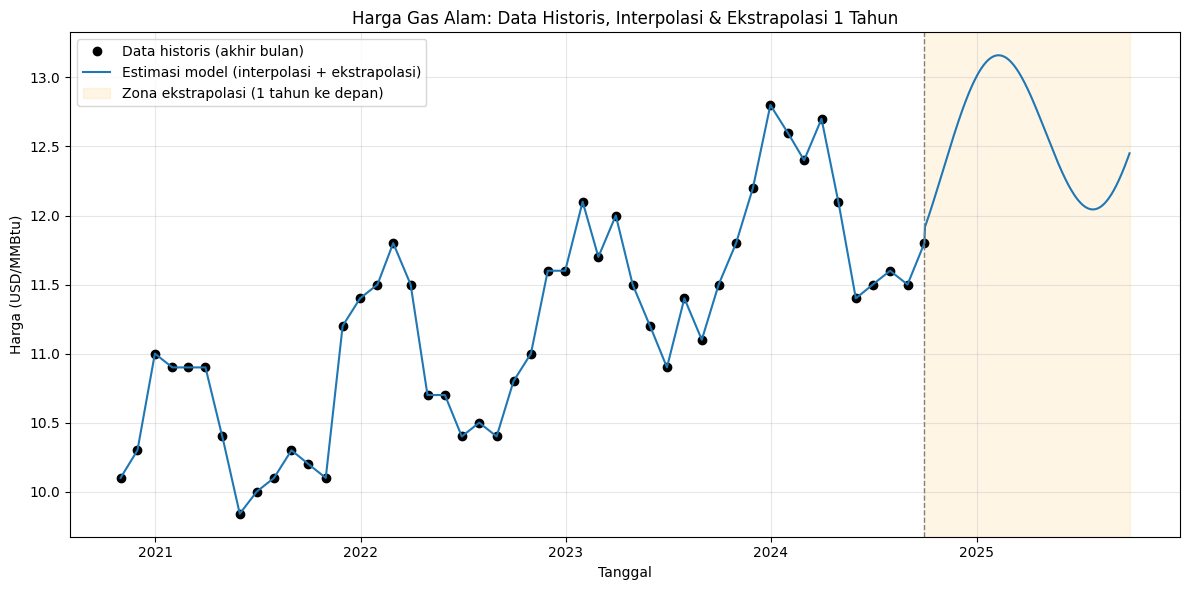

In [ ]:
future_dates = pd.date_range(END_DATE + pd.Timedelta(days=1), EXTRAPOLATION_LIMIT, freq="D")
future_prices = [estimate_price(dte) for dte in future_dates]

all_dates_smooth = pd.date_range(START_DATE, EXTRAPOLATION_LIMIT, freq="D")
smooth_prices = [estimate_price(dte) for dte in all_dates_smooth]

plt.figure(figsize=(12, 6))
plt.plot(df["Dates"], df["Prices"], "o", color="black", label="Data historis (akhir bulan)")
plt.plot(all_dates_smooth, smooth_prices, "-", color="tab:blue", linewidth=1.5,
         label="Estimasi model (interpolasi + ekstrapolasi)")
plt.axvspan(END_DATE, EXTRAPOLATION_LIMIT, color="orange", alpha=0.1, label="Zona ekstrapolasi (1 tahun ke depan)")
plt.axvline(END_DATE, color="gray", linestyle="--", linewidth=1)
plt.title("Harga Gas Alam: Data Historis, Interpolasi & Ekstrapolasi 1 Tahun")
plt.xlabel("Tanggal")
plt.ylabel("Harga (USD/MMBtu)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("nat_gas_forecast.png", dpi=150)
plt.show()

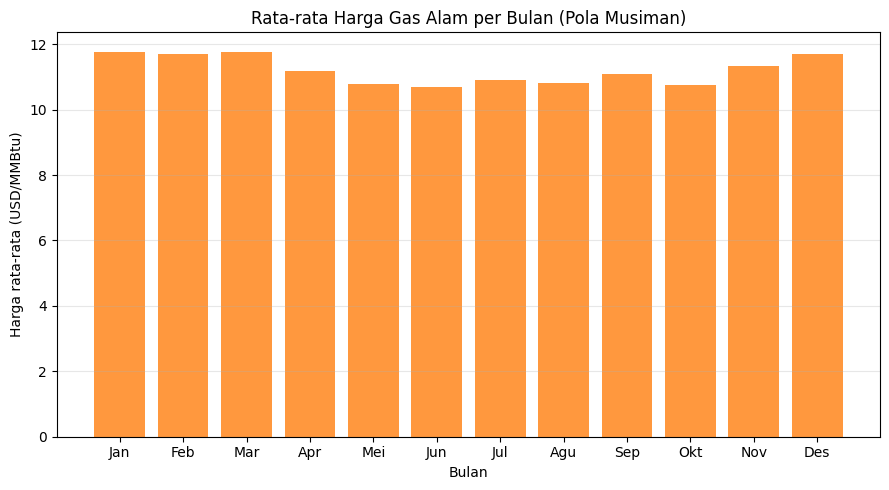

In [ ]:
# Plot pola musiman rata-rata per bulan (untuk melihat pola musim dengan jelas)
df["Month"] = df["Dates"].dt.month
monthly_avg = df.groupby("Month")["Prices"].mean()
month_names = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]

plt.figure(figsize=(9, 5))
plt.bar(month_names, monthly_avg.reindex(range(1, 13)), color="tab:orange", alpha=0.8)
plt.title("Rata-rata Harga Gas Alam per Bulan (Pola Musiman)")
plt.xlabel("Bulan")
plt.ylabel("Harga rata-rata (USD/MMBtu)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("nat_gas_seasonality.png", dpi=150)
plt.show()

## 5. Contoh penggunaan

In [ ]:
if __name__ == "__main__":
    contoh_tanggal = [
        "2021-03-15",   # interpolasi historis (antar titik data)
        "2023-12-25",   # interpolasi historis (musim dingin -> harga tinggi)
        "2024-09-30",   # tepat data terakhir
        "2025-01-15",   # ekstrapolasi masa depan (musim dingin)
        "2025-07-01",   # ekstrapolasi masa depan (musim panas)
        "2025-09-30",   # batas akhir ekstrapolasi (1 tahun setelah data terakhir)
    ]
    print("Contoh estimasi harga:\n")
    for tgl in contoh_tanggal:
        print(f"  {tgl}  ->  ${estimate_price(tgl):.2f} / MMBtu")

    print(f"\nKoefisien model: intercept={a:.3f}, tren/tahun={b:.3f}, "
          f"amplitudo_sin={c:.3f}, amplitudo_cos={d:.3f}")

Contoh estimasi harga:

  2021-03-15  ->  $10.90 / MMBtu
  2023-12-25  ->  $12.68 / MMBtu
  2024-09-30  ->  $11.80 / MMBtu
  2025-01-15  ->  $13.10 / MMBtu
  2025-07-01  ->  $12.11 / MMBtu
  2025-09-30  ->  $12.45 / MMBtu

Koefisien model: intercept=10.131, tren/tahun=0.548, amplitudo_sin=0.689, amplitudo_cos=-0.026
